# WR Ceiling Diagnostic - Smoothed Target

Hipoteza: Single-game WR yards su extremely noisy. Ako postoji iracionalno veliki "irreducible error"
deo u nedeljno-nedeljnoj varijansi, onda ce svaka model arhitektura na top-10 features konvergirati u
istu MAE/R² zidu. Taj zid ne dolazi od modela, vec od target-a.

Eksperiment: Umesto `receiving_yards`, koristimo centered 3-game rolling mean
`(yards[t-1] + yards[t] + yards[t+1]) / 3` kao target. Ovo nije production target (trazi future info),
ali je perfect diagnostic:

- Ako modeli dramaticno bolji kad je target smoothed → ceiling je u noise-u target-a, ne u modelima
- Ako su metrike iste → ceiling je u feature signal-u, vise podataka/arhitekture nece pomoci

Modeli: svi iz `WR_TopN_Models_top10` - RF, XGB, LGB, ElasticNet, MLP Hybrid, MLP Quantile q50,
LSTM Improved, GRU Improved.


---
## 1. Imports


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, json, time, random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses, Model, Input
from tensorflow.keras.layers import (
    Dense, Dropout, LayerNormalization, GaussianNoise,
    LSTM, GRU, Bidirectional, Masking, Concatenate,
)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (14, 5)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow {tf.__version__}')


TensorFlow 2.21.0


---
## 2. Feature Engineering

Full Ensemble_Final pipeline da bi top-10 features postojali.


In [2]:
df = pd.read_csv('../../../data/fully combined/wr_all_weeks.csv')
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)

work_df = df.copy()

wp_rename_map = {
    'yards_wp_<25':       'yards_wp_less_than_25',
    'yards_wp_>75':       'yards_wp_greater_than_75',
    'receptions_wp_<25':  'receptions_wp_less_than_25',
    'receptions_wp_>75':  'receptions_wp_greater_than_75',
    'targets_wp_<25':     'targets_wp_less_than_25',
    'targets_wp_>75':     'targets_wp_greater_than_75',
}
work_df = work_df.rename(columns={k: v for k, v in wp_rename_map.items() if k in work_df.columns})

work_df['player_team_inferred'] = np.where(
    (work_df['home_team'] == work_df['defteam']) & (work_df['away_team'] != work_df['defteam']),
    work_df['away_team'],
    np.where(
        (work_df['away_team'] == work_df['defteam']) & (work_df['home_team'] != work_df['defteam']),
        work_df['home_team'], np.nan,
    ),
)
prev_team = work_df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
work_df['team_changed'] = (
    work_df['player_team_inferred'].notna()
    & prev_team.notna()
    & (work_df['player_team_inferred'] != prev_team)
).astype(int)

prev_season = work_df.groupby('receiver_player_id')['season'].shift(1)
work_df['is_new_season'] = (prev_season.notna() & (work_df['season'] != prev_season)).astype(int)

work_df['season_week_abs'] = (work_df['season'] - 2015) * 22 + work_df['week']
work_df['weeks_since_last_game'] = (
    work_df.groupby('receiver_player_id')['season_week_abs']
    .diff().fillna(1).clip(lower=1).astype(float)
)
work_df.drop(columns=['season_week_abs'], inplace=True)

season_career = (
    work_df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(avg_yards=('receiving_yards', 'mean'),
         avg_target_share=('target_share', 'mean'),
         avg_epa=('epa', 'mean'),
         avg_air_yard_share=('air_yard_share', 'mean'),
         avg_catch_rate=('catch_rate', 'mean'),
         games_played=('game_id', 'count'))
    .sort_values(['receiver_player_id', 'season'])
)
for c in ['avg_yards', 'avg_target_share', 'avg_epa',
          'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = (
        season_career.groupby('receiver_player_id')[c].shift(1)
    )
career_cols = [f'{c}_last_season' for c in
               ['avg_yards', 'avg_target_share', 'avg_epa',
                'avg_air_yard_share', 'avg_catch_rate', 'games_played']]
season_career = season_career[['receiver_player_id', 'season'] + career_cols]
work_df = work_df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
work_df[career_cols] = work_df[career_cols].fillna(0)

rolling_source_cols = [
    'targets', 'receptions', 'air_yards', 'yac', 'tds', 'epa', 'wpa', 'catch_rate',
    'avg_depth', 'adot', 'yac_per_reception', 'td_rate', 'explosive_plays', 'first_downs',
    'yards_per_target', 'team_pass_attempts', 'team_air_yards', 'team_epa', 'air_yard_share',
    'target_share', 'qb_completions', 'qb_attempts', 'qb_air_yards', 'qb_cpoe', 'qb_comp_pct',
    'avg_score_diff', 'trailing_pct', 'leading_pct', 'avg_quarter', 'success_rate',
    'big_play_rate', 'avg_start_yardline', 'red_zone_targets', 'end_zone_targets',
    'third_down_targets', 'fourth_down_targets', 'high_leverage_targets',
    'second_and_long_targets', 'third_and_medium_targets', 'wp_var', 'target_share_std',
    'reception_std', 'def_targets_dev', 'def_receptions_dev', 'def_yards_dev', 'def_tds_dev',
    'def_epa_dev', 'yards_Q1', 'yards_Q2', 'yards_Q3', 'yards_Q4',
    'receptions_Q1', 'receptions_Q2', 'receptions_Q3', 'receptions_Q4',
    'targets_Q1', 'targets_Q2', 'targets_Q3', 'targets_Q4',
    'lost_yards_due_to_penalty',
    'yards_wp_less_than_25', 'yards_wp_25_45', 'yards_wp_45_55',
    'yards_wp_55_75', 'yards_wp_greater_than_75',
    'receptions_wp_less_than_25', 'receptions_wp_25_45', 'receptions_wp_45_55',
    'receptions_wp_55_75', 'receptions_wp_greater_than_75',
    'targets_wp_less_than_25', 'targets_wp_25_45', 'targets_wp_45_55',
    'targets_wp_55_75', 'targets_wp_greater_than_75',
    'weeks_since_last_game',
]
available_roll_cols = [c for c in rolling_source_cols if c in work_df.columns]
grp = work_df.groupby('receiver_player_id', sort=False)
derived_cols = []
for col in available_roll_cols:
    work_df[f'{col}_lag1']  = grp[col].transform(lambda s: s.shift(1))
    work_df[f'{col}_roll5'] = grp[col].transform(
        lambda s: s.shift(1).rolling(window=5, min_periods=1).mean()
    )
    derived_cols.extend([f'{col}_lag1', f'{col}_roll5'])

momentum_sources = [
    'targets', 'receptions', 'air_yards', 'epa', 'catch_rate',
    'target_share', 'yards_per_target', 'air_yard_share',
]
momentum_cols = []
for col in momentum_sources:
    lag1_col, roll5_col = f'{col}_lag1', f'{col}_roll5'
    if lag1_col in work_df.columns and roll5_col in work_df.columns:
        mcol = f'{col}_momentum'
        work_df[mcol] = work_df[lag1_col] - work_df[roll5_col]
        momentum_cols.append(mcol)

interaction_cols = []
if 'target_share_lag1' in work_df.columns:
    work_df['target_volume_interaction'] = (
        work_df['target_share_lag1'] * work_df['pregame_total']
    )
    interaction_cols.append('target_volume_interaction')

pregame_features = [
    'pregame_spread', 'pregame_total', 'surface', 'is_dome', 'temp_f',
    'humidity_pct', 'wind_mph', 'is_rain', 'is_snow', 'is_clear',
    'season', 'week', 'team_changed', 'is_new_season',
]
all_feature_columns = (
    pregame_features + career_cols + derived_cols + momentum_cols + interaction_cols
)

model_df = work_df.copy()
lag1_all = [c for c in all_feature_columns if c.endswith('_lag1')]
model_df = model_df.loc[~model_df[lag1_all].isna().all(axis=1)].copy()
model_df = model_df.loc[:, ~model_df.columns.duplicated()]
model_df[all_feature_columns] = model_df[all_feature_columns].fillna(0)
model_df['receiving_yards_sqrt'] = np.sqrt(model_df['receiving_yards'].clip(lower=0))

model_df = model_df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)
print(f'Dataset: {model_df.shape}  |  engineered features: {len(all_feature_columns)}')


Dataset: (44396, 272)  |  engineered features: 181


---
## 3. Top-10 Features + Season Split


In [3]:
selected_features = [
    'first_downs_roll5',
    'target_share_std_lag1',
    'targets_roll5',
    'air_yards_roll5',
    'pregame_total',
    'avg_yards_last_season',
    'avg_start_yardline_roll5',
    'wind_mph',
    'target_share_std_roll5',
    'air_yard_share_roll5',
]

missing = [f for f in selected_features if f not in model_df.columns]
if missing:
    raise ValueError(f'Missing top-10 features: {missing}')

train_seasons = list(range(2015, 2022))
val_seasons   = [2022, 2023]
test_seasons  = [2024, 2025]

train_mask_df = model_df['season'].isin(train_seasons)
val_mask_df   = model_df['season'].isin(val_seasons)
test_mask_df  = model_df['season'].isin(test_seasons)

print(f'rows: train={train_mask_df.sum()}  val={val_mask_df.sum()}  test={test_mask_df.sum()}')
print(f'features: top-10 ({len(selected_features)})')


rows: train=29276  val=8921  test=6199
features: top-10 (10)


---
## 4. Smoothed Target Setup


In [4]:
# Centered 3-game rolling mean of receiving_yards per player
# Diagnostic only: at inference this requires knowing t+1 result, so this notebook is
# NOT production-ready. It exists to answer: "does the ceiling come from label noise?"
model_df['receiving_yards_smooth3'] = (
    model_df.groupby('receiver_player_id')['receiving_yards']
    .transform(lambda s: s.rolling(window=3, center=True, min_periods=3).mean())
)
# Drop rows where centered window is undefined (first and last game of a player-career)
n_before = len(model_df)
model_df = model_df.loc[model_df['receiving_yards_smooth3'].notna()].copy().reset_index(drop=True)
print(f'Dropped {n_before - len(model_df)} rows without full 3-game window')

# Primary target = smoothed; keep raw for diagnostic comparison
model_df['target_smooth'] = model_df['receiving_yards_smooth3']
model_df['target_raw']    = model_df['receiving_yards']
model_df['target_smooth_sqrt'] = np.sqrt(model_df['target_smooth'].clip(lower=0))

# Noise diagnostic: how far is raw game from its smoothed neighborhood?
noise = (model_df['target_raw'] - model_df['target_smooth']).values
print(f'Raw vs smoothed label:')
print(f'  std(raw - smooth) = {noise.std():.2f} yds')
print(f'  mean|raw - smooth| = {np.abs(noise).mean():.2f} yds')
print(f'  -> if models cannot beat this on raw, the gap is irreducible label noise.')

# Rebuild splits after row drop
train_mask_df = model_df['season'].isin(train_seasons)
val_mask_df   = model_df['season'].isin(val_seasons)
test_mask_df  = model_df['season'].isin(test_seasons)


Dropped 2803 rows without full 3-game window
Raw vs smoothed label:
  std(raw - smooth) = 20.76 yds
  mean|raw - smooth| = 14.75 yds
  -> if models cannot beat this on raw, the gap is irreducible label noise.


---
## 4b. Split + Scaler


In [5]:
train_df = model_df[train_mask_df].copy()
val_df   = model_df[val_mask_df].copy()
test_df  = model_df[test_mask_df].copy()

y_train_sqrt = train_df['target_smooth_sqrt'].values
y_val_sqrt   = val_df['target_smooth_sqrt'].values
y_test_sqrt  = test_df['target_smooth_sqrt'].values

# Main target in original units
y_train_main = train_df['target_smooth'].values
y_val_main   = val_df['target_smooth'].values
y_test_main  = test_df['target_smooth'].values

# Raw target (for smoothed notebook: diagnostic comparison; for raw: same as main)
y_train_raw = train_df['target_raw'].values
y_val_raw   = val_df['target_raw'].values
y_test_raw  = test_df['target_raw'].values

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[selected_features].values)
X_val   = scaler.transform(val_df[selected_features].values)
X_test  = scaler.transform(test_df[selected_features].values)

mean_y_train = np.mean(np.clip(y_train_main, 0, None))
sw_train = 1.0 + 0.6 * np.sqrt(np.clip(y_train_main, 0, None) / mean_y_train)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Sample weights: [{sw_train.min():.2f}, {sw_train.max():.2f}]')


Train: (27542, 10)  Val: (8523, 10)  Test: (5528, 10)
Sample weights: [1.00, 2.36]


---
## 5. Utilities


In [6]:
def eval_preds(y_true, y_pred):
    return {
        'MAE':  float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2':   float(r2_score(y_true, y_pred)),
    }

def sqrt_to_orig(p):
    return np.clip(p, 0, None) ** 2

predictions = {}   # name -> {'val': array, 'test': array} (in original yard units)
results = {}       # name -> metric dicts

def log_result(name, val_metrics, test_metrics, seconds=None):
    results[name] = {'val': val_metrics, 'test': test_metrics, 'seconds': seconds}
    s = ''
    print(f'{name:<22}{s:>10}  val MAE={val_metrics["MAE"]:.3f}  '
          f'test MAE={test_metrics["MAE"]:.3f}  R2={test_metrics["R2"]:.4f}')


---
## 6. Tabular Models


In [7]:
# --- 5.1 RandomForest
t0 = time.time()
rf = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=4,
    random_state=SEED, n_jobs=-1,
)
rf.fit(X_train, y_train_sqrt, sample_weight=sw_train)
rf_val  = sqrt_to_orig(rf.predict(X_val))
rf_test = sqrt_to_orig(rf.predict(X_test))
predictions['RandomForest'] = {'val': rf_val, 'test': rf_test}
log_result('RandomForest',
           eval_preds(y_val_main,  rf_val),
           eval_preds(y_test_main, rf_test),
           time.time() - t0)

# --- 5.2 XGBoost
t0 = time.time()
xgb = XGBRegressor(
    n_estimators=800, max_depth=6, learning_rate=0.03,
    subsample=0.85, colsample_bytree=0.85,
    min_child_weight=4, gamma=0.1,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, tree_method='hist', verbosity=0,
)
xgb.fit(X_train, y_train_sqrt, sample_weight=sw_train,
        eval_set=[(X_val, y_val_sqrt)], verbose=False)
xgb_val  = sqrt_to_orig(xgb.predict(X_val))
xgb_test = sqrt_to_orig(xgb.predict(X_test))
predictions['XGBoost'] = {'val': xgb_val, 'test': xgb_test}
log_result('XGBoost',
           eval_preds(y_val_main,  xgb_val),
           eval_preds(y_test_main, xgb_test),
           time.time() - t0)

# --- 5.3 LightGBM
t0 = time.time()
lgb = LGBMRegressor(
    n_estimators=1000, num_leaves=63, learning_rate=0.03,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=5,
    min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1,
    random_state=SEED, verbosity=-1,
)
lgb.fit(X_train, y_train_sqrt, sample_weight=sw_train,
        eval_set=[(X_val, y_val_sqrt)])
lgb_val  = sqrt_to_orig(lgb.predict(X_val))
lgb_test = sqrt_to_orig(lgb.predict(X_test))
predictions['LightGBM'] = {'val': lgb_val, 'test': lgb_test}
log_result('LightGBM',
           eval_preds(y_val_main,  lgb_val),
           eval_preds(y_test_main, lgb_test),
           time.time() - t0)

# --- 5.4 ElasticNet
t0 = time.time()
enet = ElasticNet(alpha=0.01, l1_ratio=0.3, max_iter=20000, random_state=SEED)
enet.fit(X_train, y_train_sqrt, sample_weight=sw_train)
enet_val  = sqrt_to_orig(enet.predict(X_val))
enet_test = sqrt_to_orig(enet.predict(X_test))
predictions['ElasticNet'] = {'val': enet_val, 'test': enet_test}
log_result('ElasticNet',
           eval_preds(y_val_main,  enet_val),
           eval_preds(y_test_main, enet_test),
           time.time() - t0)


RandomForest                      val MAE=11.324  test MAE=11.331  R2=0.5899
XGBoost                           val MAE=11.401  test MAE=11.415  R2=0.5796
LightGBM                          val MAE=11.529  test MAE=11.592  R2=0.5657
ElasticNet                        val MAE=11.580  test MAE=11.519  R2=0.5797


In [8]:
MODEL_B_PARAMS = {
    'n_layers': 5,
    'units': [448, 128, 320, 448, 256],
    'dropout': 0.5,
    'huber_delta': 0.5,
    'lr': 0.003701177981657943,
    'weight_decay': 1.5007044511603625e-05,
    'batch_size': 32,
}

def build_hybrid_mlp(input_dim, params, loss_fn, noise_stddev=0.15):
    model = keras.Sequential()
    model.add(Input(shape=(input_dim,)))
    model.add(GaussianNoise(noise_stddev))
    for i in range(params['n_layers']):
        model.add(Dense(params['units'][i], activation='relu'))
        model.add(LayerNormalization())
        dr = params['dropout'] * (0.5 if i >= params['n_layers'] - 1 else 1.0)
        model.add(Dropout(dr))
    model.add(Dense(1))
    opt = optimizers.AdamW(learning_rate=params['lr'],
                           weight_decay=params['weight_decay'])
    model.compile(optimizer=opt, loss=loss_fn, metrics=['mae'])
    return model


# --- 5.5 MLP Hybrid (Huber)
t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

mlp_h = build_hybrid_mlp(X_train.shape[1], MODEL_B_PARAMS,
                         losses.Huber(delta=MODEL_B_PARAMS['huber_delta']))
cb_h = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                patience=10, min_lr=1e-6),
]
mlp_h.fit(X_train, y_train_sqrt, sample_weight=sw_train,
          validation_data=(X_val, y_val_sqrt),
          epochs=500, batch_size=MODEL_B_PARAMS['batch_size'],
          callbacks=cb_h, verbose=0)

mlp_h_val  = sqrt_to_orig(mlp_h.predict(X_val,  verbose=0).flatten())
mlp_h_test = sqrt_to_orig(mlp_h.predict(X_test, verbose=0).flatten())
predictions['MLP Hybrid'] = {'val': mlp_h_val, 'test': mlp_h_test}
log_result('MLP Hybrid',
           eval_preds(y_val_main,  mlp_h_val),
           eval_preds(y_test_main, mlp_h_test),
           time.time() - t0)


# --- 5.6 MLP Quantile q50 (pinball loss)
def pinball_loss_q50(y_true, y_pred):
    e = y_true - y_pred
    return tf.reduce_mean(tf.maximum(0.5 * e, (0.5 - 1.0) * e))

t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

mlp_q = build_hybrid_mlp(X_train.shape[1], MODEL_B_PARAMS, pinball_loss_q50)
cb_q = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                patience=10, min_lr=1e-6),
]
mlp_q.fit(X_train, y_train_sqrt, sample_weight=sw_train,
          validation_data=(X_val, y_val_sqrt),
          epochs=500, batch_size=MODEL_B_PARAMS['batch_size'],
          callbacks=cb_q, verbose=0)

mlp_q_val  = sqrt_to_orig(mlp_q.predict(X_val,  verbose=0).flatten())
mlp_q_test = sqrt_to_orig(mlp_q.predict(X_test, verbose=0).flatten())
predictions['MLP Quantile q50'] = {'val': mlp_q_val, 'test': mlp_q_test}
log_result('MLP Quantile q50',
           eval_preds(y_val_main,  mlp_q_val),
           eval_preds(y_test_main, mlp_q_test),
           time.time() - t0)



MLP Hybrid                        val MAE=11.248  test MAE=11.261  R2=0.5939
MLP Quantile q50                  val MAE=11.178  test MAE=11.247  R2=0.5893


---
## 7. Sequence Models

Top-10 features kao sequence channels, `seq_len=12`, smoothed target.


In [9]:
SEQ_LEN = 12

# Sequence scaler: fit on train only
seq_scaler = StandardScaler().fit(
    model_df.loc[train_mask_df, selected_features]
)
df_seq = model_df.copy()
df_seq[selected_features] = seq_scaler.transform(df_seq[selected_features])
df_seq['target_for_seq'] = model_df['target_smooth'].values


def build_padded_career_sequences(df_scaled, feat_cols, seq_len):
    X_seq, X_static, y_sqrt, y_orig, seasons_arr = [], [], [], [], []
    for pid, group in df_scaled.groupby('receiver_player_id'):
        group = group.sort_values(['season', 'week'])
        n = len(group)
        if n < 2:
            continue
        seq_vals    = group[feat_cols].values
        yards       = group['target_for_seq'].values
        season_vals = group['season'].values
        for t in range(1, n):
            start = max(0, t - seq_len)
            past = seq_vals[start:t]
            if past.shape[0] < seq_len:
                pad = np.zeros((seq_len - past.shape[0], len(feat_cols)))
                past = np.vstack([pad, past])
            X_seq.append(past)
            X_static.append(seq_vals[t])
            y_sqrt.append(np.sqrt(max(yards[t], 0)))
            y_orig.append(yards[t])
            seasons_arr.append(season_vals[t])
    return (
        np.array(X_seq,    dtype=np.float32),
        np.array(X_static, dtype=np.float32),
        np.array(y_sqrt,   dtype=np.float32),
        np.array(y_orig,   dtype=np.float32),
        np.array(seasons_arr),
    )

t0 = time.time()
X_seq_all, X_static_all, y_sqrt_all, y_orig_all, seasons_all = \
    build_padded_career_sequences(df_seq, selected_features, SEQ_LEN)
print(f'Built {len(X_seq_all)} sequences in {time.time()-t0:.1f}s')

tr = np.isin(seasons_all, train_seasons)
va = np.isin(seasons_all, val_seasons)
te = np.isin(seasons_all, test_seasons)

X_seq_tr,    X_seq_va,    X_seq_te    = X_seq_all[tr],    X_seq_all[va],    X_seq_all[te]
X_static_tr, X_static_va, X_static_te = X_static_all[tr], X_static_all[va], X_static_all[te]
y_tr_sqrt,   y_va_sqrt,   y_te_sqrt   = y_sqrt_all[tr],   y_sqrt_all[va],   y_sqrt_all[te]
y_tr_orig,   y_va_orig,   y_te_orig   = y_orig_all[tr],   y_orig_all[va],   y_orig_all[te]

# Sequence-pipeline sample ordering differs from tabular (sequences drop 1st row per player)
# so we keep sequence-aligned y arrays for per-sample comparison.
N_SEQ_FEAT    = X_seq_tr.shape[2]
N_STATIC_FEAT = X_static_tr.shape[1]
print(f'seq: train={len(y_tr_sqrt)}  val={len(y_va_sqrt)}  test={len(y_te_sqrt)}')
print(f'     n_seq_feat={N_SEQ_FEAT}  n_static_feat={N_STATIC_FEAT}')


def make_weights(strength, y_orig):
    mean_y = np.mean(np.clip(y_orig, 0, None))
    base = np.sqrt(np.clip(y_orig, 0, None) / mean_y)
    return 1.0 + strength * base


Built 40334 sequences in 0.8s
seq: train=26571  val=8352  test=5411
     n_seq_feat=10  n_static_feat=10


In [10]:
def build_rnn_fixed(rnn_type, params, seq_len, n_seq_feat, n_static_feat):
    RNNCell = LSTM if rnn_type == 'LSTM' else GRU

    seq_input = Input(shape=(seq_len, n_seq_feat), name='seq_input')
    x = Masking(mask_value=0.0)(seq_input)

    for i in range(params['n_rnn_layers']):
        units = params[f'rnn_units_{i}']
        return_seq = (i < params['n_rnn_layers'] - 1)
        rnn_layer = RNNCell(
            units, return_sequences=return_seq,
            dropout=params['rnn_dropout'],
            recurrent_dropout=params['rnn_dropout'],
        )
        if params['bidirectional']:
            x = Bidirectional(rnn_layer)(x)
        else:
            x = rnn_layer(x)
        x = LayerNormalization()(x)
        x = Dropout(params['dropout'])(x)

    static_input = Input(shape=(n_static_feat,), name='static_input')
    s = GaussianNoise(params['noise_stddev'])(static_input)
    s = Dense(params['static_units'], activation='relu')(s)
    s = LayerNormalization()(s)
    s = Dropout(params['dropout'])(s)

    merged = Concatenate()([x, s])
    merged = Dense(params['dense_units'], activation='relu')(merged)
    merged = LayerNormalization()(merged)
    merged = Dropout(params['dropout'] * 0.5)(merged)
    output = Dense(1)(merged)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    opt = optimizers.AdamW(learning_rate=params['lr'],
                           weight_decay=params['weight_decay'])
    model.compile(optimizer=opt,
                  loss=losses.Huber(delta=params['huber_delta']),
                  metrics=['mae'])
    return model


def train_rnn(rnn_type, params, name):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

    model = build_rnn_fixed(rnn_type, params, SEQ_LEN, N_SEQ_FEAT, N_STATIC_FEAT)
    sw = make_weights(params['sw_strength'], y_tr_orig)

    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                restore_best_weights=True, min_delta=1e-4),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                    patience=10, min_lr=1e-6),
    ]

    t0 = time.time()
    model.fit(
        [X_seq_tr, X_static_tr], y_tr_sqrt,
        sample_weight=sw,
        validation_data=([X_seq_va, X_static_va], y_va_sqrt),
        epochs=500, batch_size=params['batch_size'],
        callbacks=cbs, verbose=0,
    )
    elapsed = time.time() - t0

    pred_va = sqrt_to_orig(
        model.predict([X_seq_va, X_static_va], verbose=0).flatten()
    )
    pred_te = sqrt_to_orig(
        model.predict([X_seq_te, X_static_te], verbose=0).flatten()
    )
    # Note: RNN predictions live on the sequence-aligned arrays (y_{tr,va,te}_orig),
    # which are NOT the tabular y_{val,test}_main arrays. Log against sequence y's.
    predictions[name] = {
        'val_seq':  pred_va,
        'test_seq': pred_te,
        'y_val_seq':  y_va_orig,
        'y_test_seq': y_te_orig,
    }
    log_result(name,
               eval_preds(y_va_orig, pred_va),
               eval_preds(y_te_orig, pred_te),
               elapsed)
    return model


### 7.1 LSTM Improved (best HPs)

Fiksirani HPs iz `WR_RNN_Improved` Optuna best trial-a:
`seq_len=12, 1 LSTM layer x 128 units, unidirectional, dropout=0.3, Huber(0.5), lr=3.5e-4`.


In [11]:
LSTM_PARAMS = {'seq_len': 12, 'batch_size': 32, 'sw_strength': 0.6, 'bidirectional': False, 'n_rnn_layers': 1, 'dropout': 0.3, 'rnn_dropout': 0.3, 'noise_stddev': 0.2, 'huber_delta': 0.5, 'lr': 0.00034978, 'weight_decay': 0.0019053, 'rnn_units_0': 128, 'static_units': 96, 'dense_units': 64}

_ = train_rnn('LSTM', LSTM_PARAMS, 'LSTM Improved')


LSTM Improved                     val MAE=11.026  test MAE=11.139  R2=0.5990


### 7.2 GRU Improved (best HPs)

Fiksirani HPs iz `WR_RNN_Improved_GRU` Optuna best trial-a:
`seq_len=12, 1 GRU layer x 192 units, unidirectional, dropout=0.35, Huber(2.0), lr=1.4e-4`.


In [12]:
GRU_PARAMS = {'seq_len': 12, 'batch_size': 64, 'sw_strength': 0.7, 'bidirectional': False, 'n_rnn_layers': 1, 'dropout': 0.35, 'rnn_dropout': 0.1, 'noise_stddev': 0.2, 'huber_delta': 2.0, 'lr': 0.00013876, 'weight_decay': 0.000498, 'rnn_units_0': 192, 'static_units': 32, 'dense_units': 64}

_ = train_rnn('GRU', GRU_PARAMS, 'GRU Improved')


GRU Improved                      val MAE=11.179  test MAE=11.267  R2=0.5896


---
## 8. Comparison - sortirano po Test MAE (vs smoothed target)


In [13]:
rows = []
for name, r in results.items():
    rows.append({
        'Model':     name,
        'Val MAE':   round(r['val']['MAE'],   3),
        'Test MAE':  round(r['test']['MAE'],  3),
        'Test RMSE': round(r['test']['RMSE'], 3),
        'Test R2':   round(r['test']['R2'],   4),
    })
summary = pd.DataFrame(rows).sort_values('Test MAE').reset_index(drop=True)
print(summary.to_string(index=False))


           Model  Val MAE  Test MAE  Test RMSE  Test R2
   LSTM Improved   11.026    11.139     15.234   0.5990
MLP Quantile q50   11.178    11.247     15.374   0.5893
      MLP Hybrid   11.248    11.261     15.288   0.5939
    GRU Improved   11.179    11.267     15.412   0.5896
    RandomForest   11.324    11.331     15.363   0.5899
         XGBoost   11.401    11.415     15.554   0.5796
      ElasticNet   11.580    11.519     15.552   0.5797
        LightGBM   11.529    11.592     15.810   0.5657


---
## 9. Diagnostic - Smoothed vs Raw Evaluation

Za svaki model trenirali smo na smoothed target-u. Sada merimo:
- vs smoothed: glavni metric (kako dobro predvidjamo 3-game average)
- vs raw: isti prediction, ali uporedjen sa noisy single-game yards-om

Oracle floor: smoothed ground truth vs raw - to je minimum MAE koji bilo koji smoothed-trained
model moze da postigne kad se meri protiv raw labele. Ako se modelni rezultati priblizavaju oracle
floor-u kad se uporedjuju sa smoothed, a ostanu oko ~17-18 kad se uporedjuju sa raw, to je direktan
dokaz da je "ceiling" bio noise u single-game target-u.


In [14]:
# Diagnostic: for each model, also compute test-set metrics versus the RAW label
# (i.e. what if we use a smoothed-trained model to predict noisy single-game yards?).
# Also compute the "oracle" metric: smoothed ground truth vs raw target — this is the
# theoretical floor for any smoothed-target model evaluated on raw target.

def eval_seq_vs(name, y_raw_seq, y_smooth_seq, pred_seq):
    return {
        'Model': name,
        'vs smoothed MAE': round(mean_absolute_error(y_smooth_seq, pred_seq), 3),
        'vs smoothed R2':  round(r2_score(y_smooth_seq, pred_seq), 4),
        'vs raw MAE':      round(mean_absolute_error(y_raw_seq, pred_seq), 3),
        'vs raw R2':       round(r2_score(y_raw_seq, pred_seq), 4),
    }

# Tabular models share y_test arrays
diag_rows = []
for name in ['RandomForest', 'XGBoost', 'LightGBM', 'ElasticNet',
             'MLP Hybrid', 'MLP Quantile q50']:
    p = predictions[name]['test']
    diag_rows.append(eval_seq_vs(name, y_test_raw, y_test_main, p))

# Sequence models use sequence-aligned y arrays. We need the RAW target on the
# same sequence ordering. Rebuild it quickly by running sequence construction on raw.
raw_seq_map = df_seq[['receiver_player_id', 'season', 'week']].copy()
raw_seq_map['target_raw'] = model_df['target_raw'].values
raw_aligned = []
for pid, group in raw_seq_map.groupby('receiver_player_id'):
    group = group.sort_values(['season', 'week'])
    if len(group) < 2:
        continue
    raw_aligned.extend(group['target_raw'].values[1:])
raw_aligned = np.array(raw_aligned, dtype=np.float32)
raw_te_seq = raw_aligned[te]

for name in ['LSTM Improved', 'GRU Improved']:
    p = predictions[name]['test_seq']
    y_smooth_te_seq = predictions[name]['y_test_seq']
    diag_rows.append(eval_seq_vs(name, raw_te_seq, y_smooth_te_seq, p))

diag_df = pd.DataFrame(diag_rows).sort_values('vs smoothed MAE').reset_index(drop=True)
print('=== Smoothed-trained models: smoothed vs raw evaluation ===')
print(diag_df.to_string(index=False))

# Oracle floor (tabular test set): if we had the perfect smoothed target and used it
# to predict the raw target, this is the achievable error.
oracle_mae = mean_absolute_error(y_test_raw, y_test_main)
oracle_r2  = r2_score(y_test_raw, y_test_main)
print()
print(f'Oracle floor (smoothed ground truth vs raw target):')
print(f'  MAE = {oracle_mae:.3f}   R2 = {oracle_r2:.4f}')
print(f'This is the minimum possible MAE for any smoothed-target model evaluated on raw.')

os.makedirs('../../../results', exist_ok=True)
diag_df.to_csv('../../../results/wr_ceiling_smoothed_vs_raw.csv', index=False)
print()
print('Saved: ../../../results/wr_ceiling_smoothed_vs_raw.csv')


=== Smoothed-trained models: smoothed vs raw evaluation ===
           Model  vs smoothed MAE  vs smoothed R2  vs raw MAE  vs raw R2
   LSTM Improved           11.139          0.5990      18.711     0.3088
MLP Quantile q50           11.247          0.5893      18.484     0.3152
      MLP Hybrid           11.261          0.5939      18.613     0.3182
    GRU Improved           11.267          0.5896      18.681     0.3139
    RandomForest           11.331          0.5899      18.696     0.3162
         XGBoost           11.415          0.5796      18.650     0.3146
      ElasticNet           11.519          0.5797      18.877     0.3031
        LightGBM           11.592          0.5657      18.755     0.3055

Oracle floor (smoothed ground truth vs raw target):
  MAE = 14.164   R2 = 0.5957
This is the minimum possible MAE for any smoothed-target model evaluated on raw.

Saved: ../../../results/wr_ceiling_smoothed_vs_raw.csv


---
## 11. Rank Correlation (Spearman)

Pored MAE/R², za svaki model racunamo Spearman rank correlation izmedju predictions
i stvarnih vrednosti. Rank correlation meri da li model ispravno ordinira igrace -
to je ono sto treba za DFS value stacking, betting over/under sortiranje, i bilo kakav
use case gde je relativno rangiranje vaznije od apsolutnih brojeva.

Ocekujemo visu Spearman rank corr nego R² jer rank metric ne penalizuje sistematski
shift / scaling - samo redosled. Za smoothed target: rank corr ~0.65-0.75. Za raw:
~0.50-0.60.

Ovo je poslednji diagnostic - zaokruzuje "ceiling story" (3-game window).


=== Rank correlation — Spearman ρ ===
           Model  Spearman vs smoothed  Spearman vs raw
   LSTM Improved                0.7751           0.5575
MLP Quantile q50                0.7684           0.5604
      MLP Hybrid                0.7672           0.5594
    GRU Improved                0.7664           0.5571
    RandomForest                0.7643           0.5591
      ElasticNet                0.7633           0.5515
         XGBoost                0.7580           0.5554
        LightGBM                0.7513           0.5511

=== Rank vs R² gap (positive = model ranks better than it predicts magnitudes) ===
           Model  Spearman vs smoothed  Test R² (vs smoothed)  Rank − R² gap
   LSTM Improved                0.7751                 0.5990         0.1761
MLP Quantile q50                0.7684                 0.5893         0.1791
      MLP Hybrid                0.7672                 0.5939         0.1733
    GRU Improved                0.7664                 0.5896     

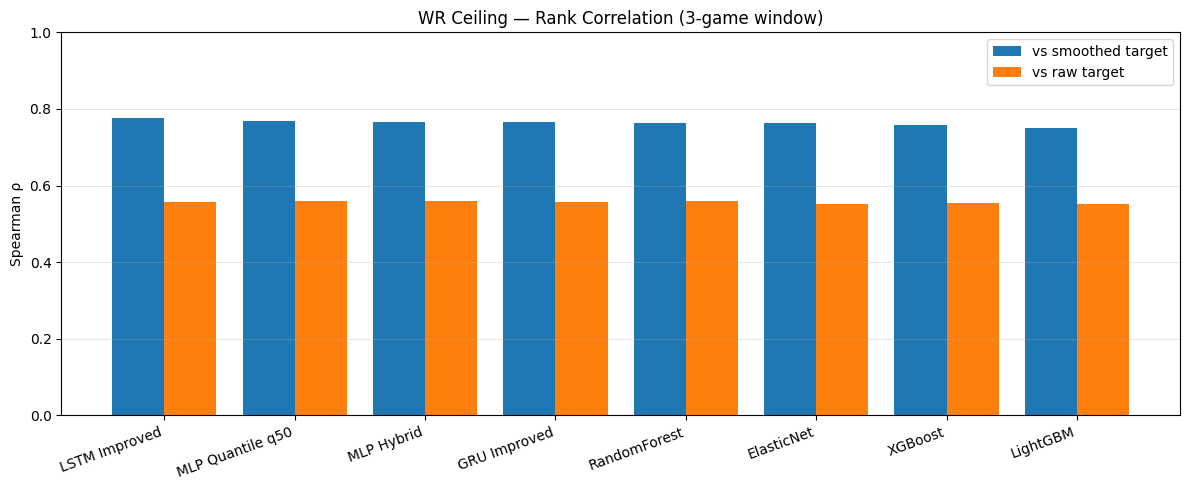

Saved: ../../../results/wr_ceiling_smoothed_rank_corr.png


In [15]:
from scipy.stats import spearmanr

rank_rows = []

# Tabular models: predictions aligned with y_test_main / y_test_raw
for name in ['RandomForest', 'XGBoost', 'LightGBM', 'ElasticNet',
             'MLP Hybrid', 'MLP Quantile q50']:
    p = predictions[name]['test']
    rho_smooth, _ = spearmanr(p, y_test_main)
    rho_raw,    _ = spearmanr(p, y_test_raw)
    rank_rows.append({
        'Model': name,
        'Spearman vs smoothed': round(rho_smooth, 4),
        'Spearman vs raw':      round(rho_raw, 4),
    })

# Sequence models: use sequence-aligned y arrays (from section 9: raw_te_seq)
for name in ['LSTM Improved', 'GRU Improved']:
    p = predictions[name]['test_seq']
    y_smooth_seq = predictions[name]['y_test_seq']
    rho_smooth, _ = spearmanr(p, y_smooth_seq)
    rho_raw,    _ = spearmanr(p, raw_te_seq)
    rank_rows.append({
        'Model': name,
        'Spearman vs smoothed': round(rho_smooth, 4),
        'Spearman vs raw':      round(rho_raw, 4),
    })

rank_df = pd.DataFrame(rank_rows).sort_values('Spearman vs smoothed', ascending=False)
rank_df = rank_df.reset_index(drop=True)
print('=== Rank correlation — Spearman ρ ===')
print(rank_df.to_string(index=False))

# Diagnostic: compare rank corr vs R² head-to-head
r2_vs_smooth = {name: results[name]['test']['R2'] for name in rank_df['Model']}
rank_df['Test R² (vs smoothed)'] = rank_df['Model'].map(r2_vs_smooth).round(4)
rank_df['Rank − R² gap'] = (rank_df['Spearman vs smoothed']
                            - rank_df['Test R² (vs smoothed)']).round(4)
print()
print('=== Rank vs R² gap (positive = model ranks better than it predicts magnitudes) ===')
print(rank_df[['Model', 'Spearman vs smoothed', 'Test R² (vs smoothed)',
               'Rank − R² gap']].to_string(index=False))

os.makedirs('../../../results', exist_ok=True)
rank_df.to_csv('../../../results/wr_ceiling_smoothed_rank_corr.csv', index=False)
print()
print('Saved: ../../../results/wr_ceiling_smoothed_rank_corr.csv')


fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(rank_df))
ax.bar(x - 0.2, rank_df['Spearman vs smoothed'], 0.4, label='vs smoothed target')
ax.bar(x + 0.2, rank_df['Spearman vs raw'],      0.4, label='vs raw target')
ax.set_xticks(x)
ax.set_xticklabels(rank_df['Model'], rotation=20, ha='right')
ax.set_ylabel('Spearman ρ')
ax.set_ylim(0, 1.0)
ax.set_title('WR Ceiling — Rank Correlation (3-game window)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../../../results/wr_ceiling_smoothed_rank_corr.png', dpi=120)
plt.show()
print('Saved: ../../../results/wr_ceiling_smoothed_rank_corr.png')
